# Fraud Detection — Advanced Models
### IEEE-CIS Fraud Detection Dataset
This notebook builds Advance models Random Forest and XGBoost models, compare them against our baselines, and find the best performing model for fraud detection.

In [2]:
import sys
!{sys.executable} -m pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
    --------------------------------------- 1.0/69.5 MB 7.1 MB/s eta 0:00:10
   - -------------------------------------- 2.9/69.5 MB 8.4 MB/s eta 0:00:08
   -- ------------------------------------- 4.5/69.5 MB 8.4 MB/s eta 0:00:08
   --- ------------------------------------ 6.3/69.5 MB 8.0 MB/s eta 0:00:08
   ---- ----------------------------------- 8.4/69.5 MB 8.4 MB/s eta 0:00:08
   ----- ---------------------------------- 10.0/69.5 MB 8.3 MB/s eta 0:00:08
   ------ --------------------------------- 11.0/69.5 MB 8.0 MB/s eta 0:00:08
   ------- -------------------------------- 12.3/69.5 MB 7.6 MB/s eta 0:00:08
   ------- -------------------------------- 12.8/69.5 MB 7.5 MB/s eta 0:00:08
   ------- -------------------------------- 13.4/69.5 MB 6.7 MB/s eta 0:00:09
   -------- ------------------------------- 14.7/69.5 MB 6.5 MB/s eta 0:00:09
   --------- ------------------------------ 15.7/69.5 MB 6.6 MB/s eta 0:00:09

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 50)

In [4]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (911804, 431)
X_test:  (118108, 431)


In [5]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("=" * 40)
print(classification_report(y_test, rf_preds, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_probs):.4f}")

Random Forest Results
              precision    recall  f1-score   support

       Legit       0.98      0.99      0.99    113975
       Fraud       0.61      0.50      0.55      4133

    accuracy                           0.97    118108
   macro avg       0.80      0.74      0.77    118108
weighted avg       0.97      0.97      0.97    118108

ROC-AUC: 0.8935


In [7]:
xgb_model = XGBClassifier(
    n_estimators=120,
    max_depth=8,
    learning_rate=0.4,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Results")
print("=" * 40)
print(classification_report(y_test, xgb_preds, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_probs):.4f}")

XGBoost Results
              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99    113975
       Fraud       0.90      0.59      0.71      4133

    accuracy                           0.98    118108
   macro avg       0.94      0.80      0.85    118108
weighted avg       0.98      0.98      0.98    118108

ROC-AUC: 0.9525


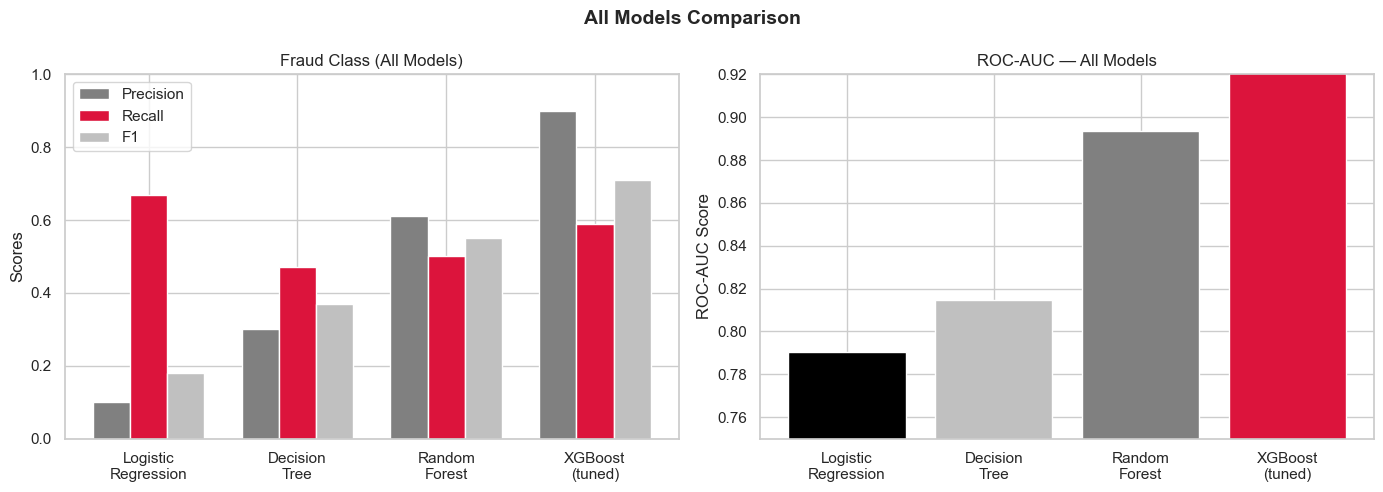

In [13]:
models = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest', 'XGBoost\n(tuned)']
precision_scores = [0.10, 0.30, 0.61, 0.90]
recall_scores =    [0.67, 0.47, 0.50, 0.59]
f1_scores =        [0.18, 0.37, 0.55, 0.71]
roc_auc_scores =   [0.7902, 0.8146, 0.8935, 0.9525]

x = np.arange(len(models))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - width, precision_scores, width, label='Precision', color='grey')
axes[0].bar(x,         recall_scores,    width, label='Recall',    color='crimson')
axes[0].bar(x + width, f1_scores,        width, label='F1',        color='silver')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1)
axes[0].set_title('Fraud Class (All Models)')
axes[0].set_ylabel('Scores')
axes[0].legend()

axes[1].bar(models, roc_auc_scores, color = ['black', 'silver', 'grey', 'crimson'], edgecolor='white')
axes[1].set_ylim(0.75, 0.92)
axes[1].set_title('ROC-AUC — All Models')
axes[1].set_ylabel('ROC-AUC Score')

plt.suptitle('All Models Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()